프로젝트 1 : 손수 설계하는 선형회귀, 당뇨병 수치를 맞춰보자!
===

In [1]:
# sklearn.datasets의 load_diabetes에서 데이터 가져오기
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
# 데이터 가져오기

# diabetes의 data를 df_X에, target을 df_y에 저장
data = load_diabetes()
df_X = data.data
df_y = data.target
print(data.feature_names)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [3]:
# 모델에 입력할 데이터 X 준비하기

# df_X에 있는 값들을 numpy array로 변환해서 저장
X = np.array(df_X)

print(type(X), X.dtype)

<class 'numpy.ndarray'> float64


In [4]:
# 모델에 예측할 데이터 y 준비하기

# df_y에 있는 값들을 numpy array로 변환해서 저장
y = np.array(df_y)

print(type(y), y.dtype)

<class 'numpy.ndarray'> float64


In [5]:
# train 데이터와 test 데이터로 분리하기

# X와 y 데이터를 각각 train 데이터와 test 데이터로 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Iteration 3000 : Loss 
# 전체 그대로 : 2907
# [0, 1, 2, 3, 4, 5, 6, 7, 8]: 2907
# [0, 1, 2, 3, 4, 5, 7, 8]: 2925
# [0, 1, 2, 3, 4, 7, 8]: 2925 *
# 나머지는 제거하면 동일 조건에서 3000대 이상으로 올라감

X_train = X_train[:, [0, 1, 2, 3, 4, 7, 8]]
X_test = X_test[:, [0, 1, 2, 3, 4, 7, 8]]


print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 7) (353,)
(89, 7) (89,)


In [6]:
# 모델 준비하기

# 입력 데이터 개수에 맞는 가중치 W와 b를 준비
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

# 모델 함수를 구현
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

7


In [7]:
# 손실함수를 MSE 함수로 정의
def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

# 손실함수 loss 정의하기
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [8]:
# 기울기를 구하는 gradient 함수 구현하기

# 기울기를 계산하는 gradient 함수를 구현
def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

In [9]:
# 하이퍼 파라미터인 학습률 설정하기

# 학습률, learning rate 를 설정
# LEARNING_RATE = 0.001
# LEARNING_RATE = 0.01

# LEARNING_RATE = 0.1 # 그래프 y축 로스 최대 25000 찍힘, 11번 예측 데이터 그래프 분포의 분산 부족해 보임
# LEARNING_RATE = 0.15 # 그래프 y축 로스 최대 18000 찍힘

LEARNING_RATE = 0.2 
# y축 14000, 11번 예측 데이터 그래프 정답 데이터와 겹치는게 조금 더 많고 0.15보다 미세하게 더 분포가 분산됨

#만약 학습이 잘 되지 않는다면 learning rate 값을 한번 여러 가지로 설정하며 실험

losses = []

In [10]:
%%timeit -n 1 -r 1
global W, b


# 모델 학습하기

# 정의된 손실함수와 기울기 함수로 모델을 학습
# loss값이 충분히 떨어질 때까지 학습을 진행
# 입력하는 데이터인 X에 들어가는 특성 컬럼들을 몇 개 빼도 괜찮습니다. 다양한 데이터로 실험

# 혈청 's2', 's3', 's6' 피처는 제외하더라도 오차 상승(약 +18)이 미미함을 확인 완료하여 제외함

for i in range(1, 3001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))


Iteration 100 : Loss 5075.0304
Iteration 200 : Loss 4451.0571
Iteration 300 : Loss 4047.7681
Iteration 400 : Loss 3779.8015
Iteration 500 : Loss 3595.9347
Iteration 600 : Loss 3465.2645
Iteration 700 : Loss 3369.0067
Iteration 800 : Loss 3295.6254
Iteration 900 : Loss 3237.9385
Iteration 1000 : Loss 3191.3928
Iteration 1100 : Loss 3153.0364
Iteration 1200 : Loss 3120.9021
Iteration 1300 : Loss 3093.6375
Iteration 1400 : Loss 3070.2811
Iteration 1500 : Loss 3050.1257
Iteration 1600 : Loss 3032.6344
Iteration 1700 : Loss 3017.3873
Iteration 1800 : Loss 3004.0486
Iteration 1900 : Loss 2992.3441
Iteration 2000 : Loss 2982.0463
Iteration 2100 : Loss 2972.9649
Iteration 2200 : Loss 2964.9384
Iteration 2300 : Loss 2957.8297
Iteration 2400 : Loss 2951.5213
Iteration 2500 : Loss 2945.9123
Iteration 2600 : Loss 2940.9156
Iteration 2700 : Loss 2936.4562
Iteration 2800 : Loss 2932.4688
Iteration 2900 : Loss 2928.8971
Iteration 3000 : Loss 2925.6921
298 ms ± 0 ns per loop (mean ± std. dev. of 1 run

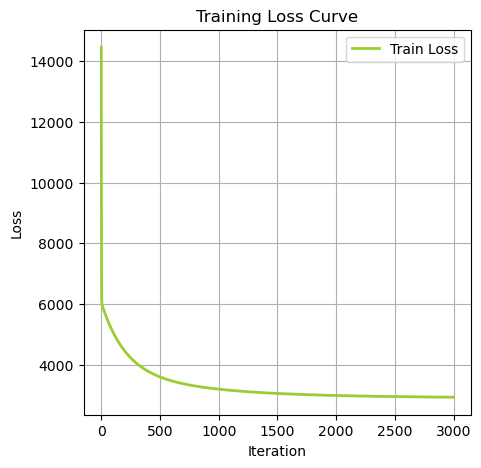

In [11]:
# 그래프 크기 설정
plt.figure(figsize=(5, 5))

# x축은 학습 횟수(Iteration), y축은 해당 시점의 Loss 값
plt.plot(losses, label='Train Loss', color='yellowgreen', linewidth=2)

# 그래프 레이블 및 타이틀 설정
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True) # 눈금선 표시
plt.legend()

# 그래프 출력
plt.show()

In [12]:
# test 데이터에 대한 성능 확인하기
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(2862.2691944954768)

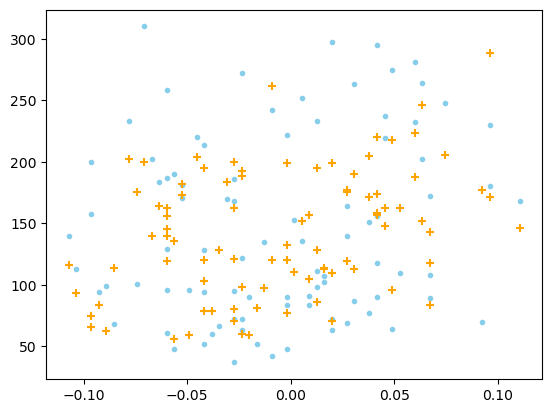

In [13]:
# 정답 데이터와 예측한 데이터 시각화하기

# x축에는 X 데이터의 첫 번째 컬럼
# y축에는 정답인 target 데이터를 넣어서
# 모델이 예측한 데이터를 시각화
plt.scatter(X_test[:, 0], y_test, color="skyblue", marker=".")
plt.scatter(X_test[:, 0], prediction, color="orange", marker="+")
plt.show()

프로젝트 2 : 날씨 좋은 월요일 오후 세 시, 자전거 타는 사람은 몇 명?
===


자전거의 대여량을 예측하는 문제

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn의 LinearRegression 모델 불러오기
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.model_selection import train_test_split

In [15]:
# 데이터 가져오기

# 터미널에서 ~/data/data/bike-sharing-demand 경로에 train.csv 데이터를 train 변수로 가져옴
train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv") 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [16]:
# datetime 컬럼을 datetime 자료형으로 변환하고 연, 월, 일, 시, 분, 초까지 6가지 컬럼 생성하기

# to_datetime 활용
# datetime 컬럼을 datetime 자료형으로 변환
train['datetime'] = pd.to_datetime(train['datetime'])

# pandas datetime extract year month day 키워드로 검색해 보기
# 연, 월, 일, 시, 분, 초까지 6가지 컬럼 생성하기
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-

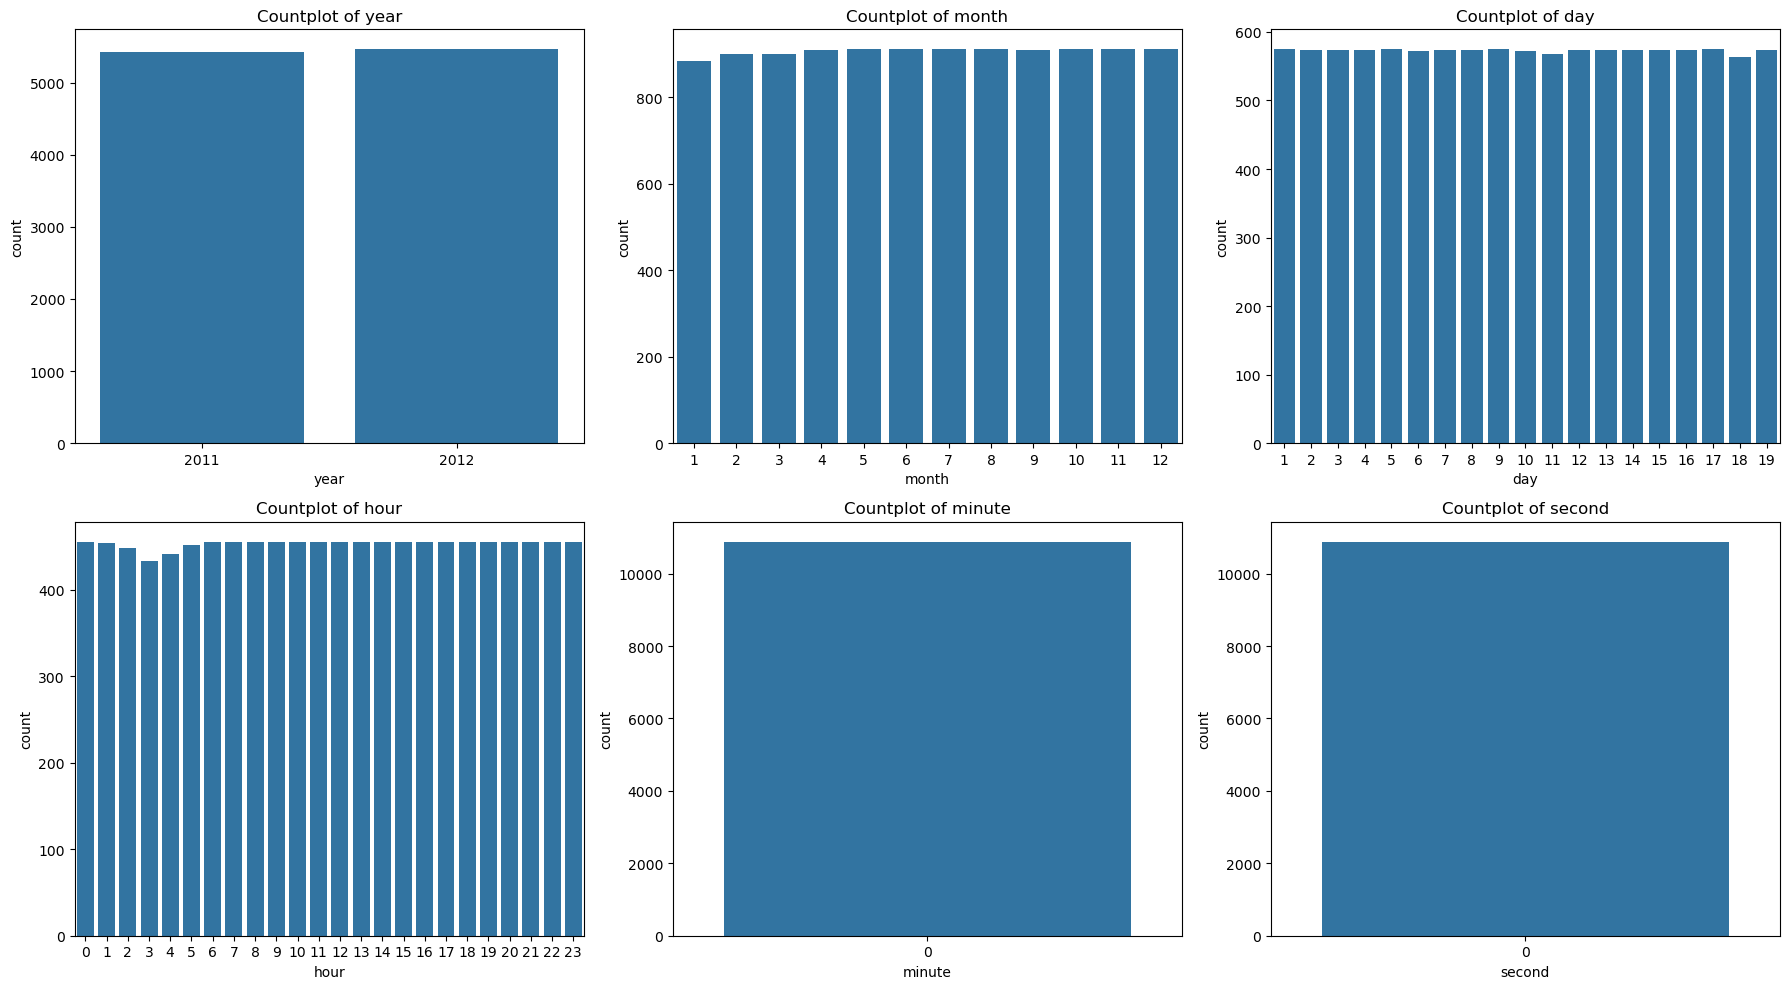

In [17]:
# year, month, day, hour, minute, second 데이터 개수 시각화하기

 # subplot을 활용해서 한 번에 6개의 그래프 함께 시각화하기
fig, axs = plt.subplots(2, 3, figsize=(18, 10)) 

cols = ['year', 'month', 'day', 'hour', 'minute', 'second']

for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax) # sns.countplot 활용해서 시각화하기
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

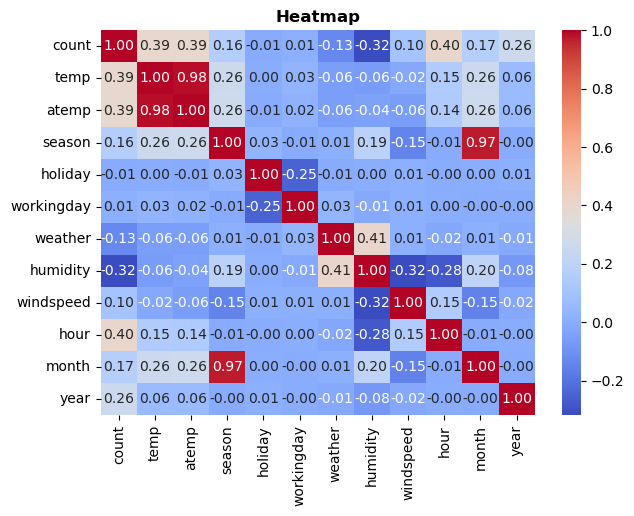

season: [1 2 3 4]
weather: [1 2 3 4]
temp: [ 9.84  9.02  8.2  13.12 15.58 14.76 17.22 18.86 18.04 16.4  13.94 12.3
 10.66  6.56  5.74  7.38  4.92 11.48  4.1   3.28  2.46 21.32 22.96 23.78
 24.6  19.68 22.14 20.5  27.06 26.24 25.42 27.88 28.7  30.34 31.16 29.52
 33.62 35.26 36.9  32.8  31.98 34.44 36.08 37.72 38.54  1.64  0.82 39.36
 41.  ]
humidity: [ 81  80  75  86  76  77  72  82  88  87  94 100  71  66  57  46  42  39
  44  47  50  43  40  35  30  32  64  69  55  59  63  68  74  51  56  52
  49  48  37  33  28  38  36  93  29  53  34  54  41  45  92  62  58  61
  60  65  70  27  25  26  31  73  21  24  23  22  19  15  67  10   8  12
  14  13  17  16  18  20  85   0  83  84  78  79  89  97  90  96  91]
windspeed: [ 0.      6.0032 16.9979 19.0012 19.9995 12.998  15.0013  8.9981 11.0014
 22.0028 30.0026 23.9994 27.9993 26.0027  7.0015 32.9975 36.9974 31.0009
 35.0008 39.0007 43.9989 40.9973 51.9987 46.0022 50.0021 43.0006 56.9969
 47.9988]


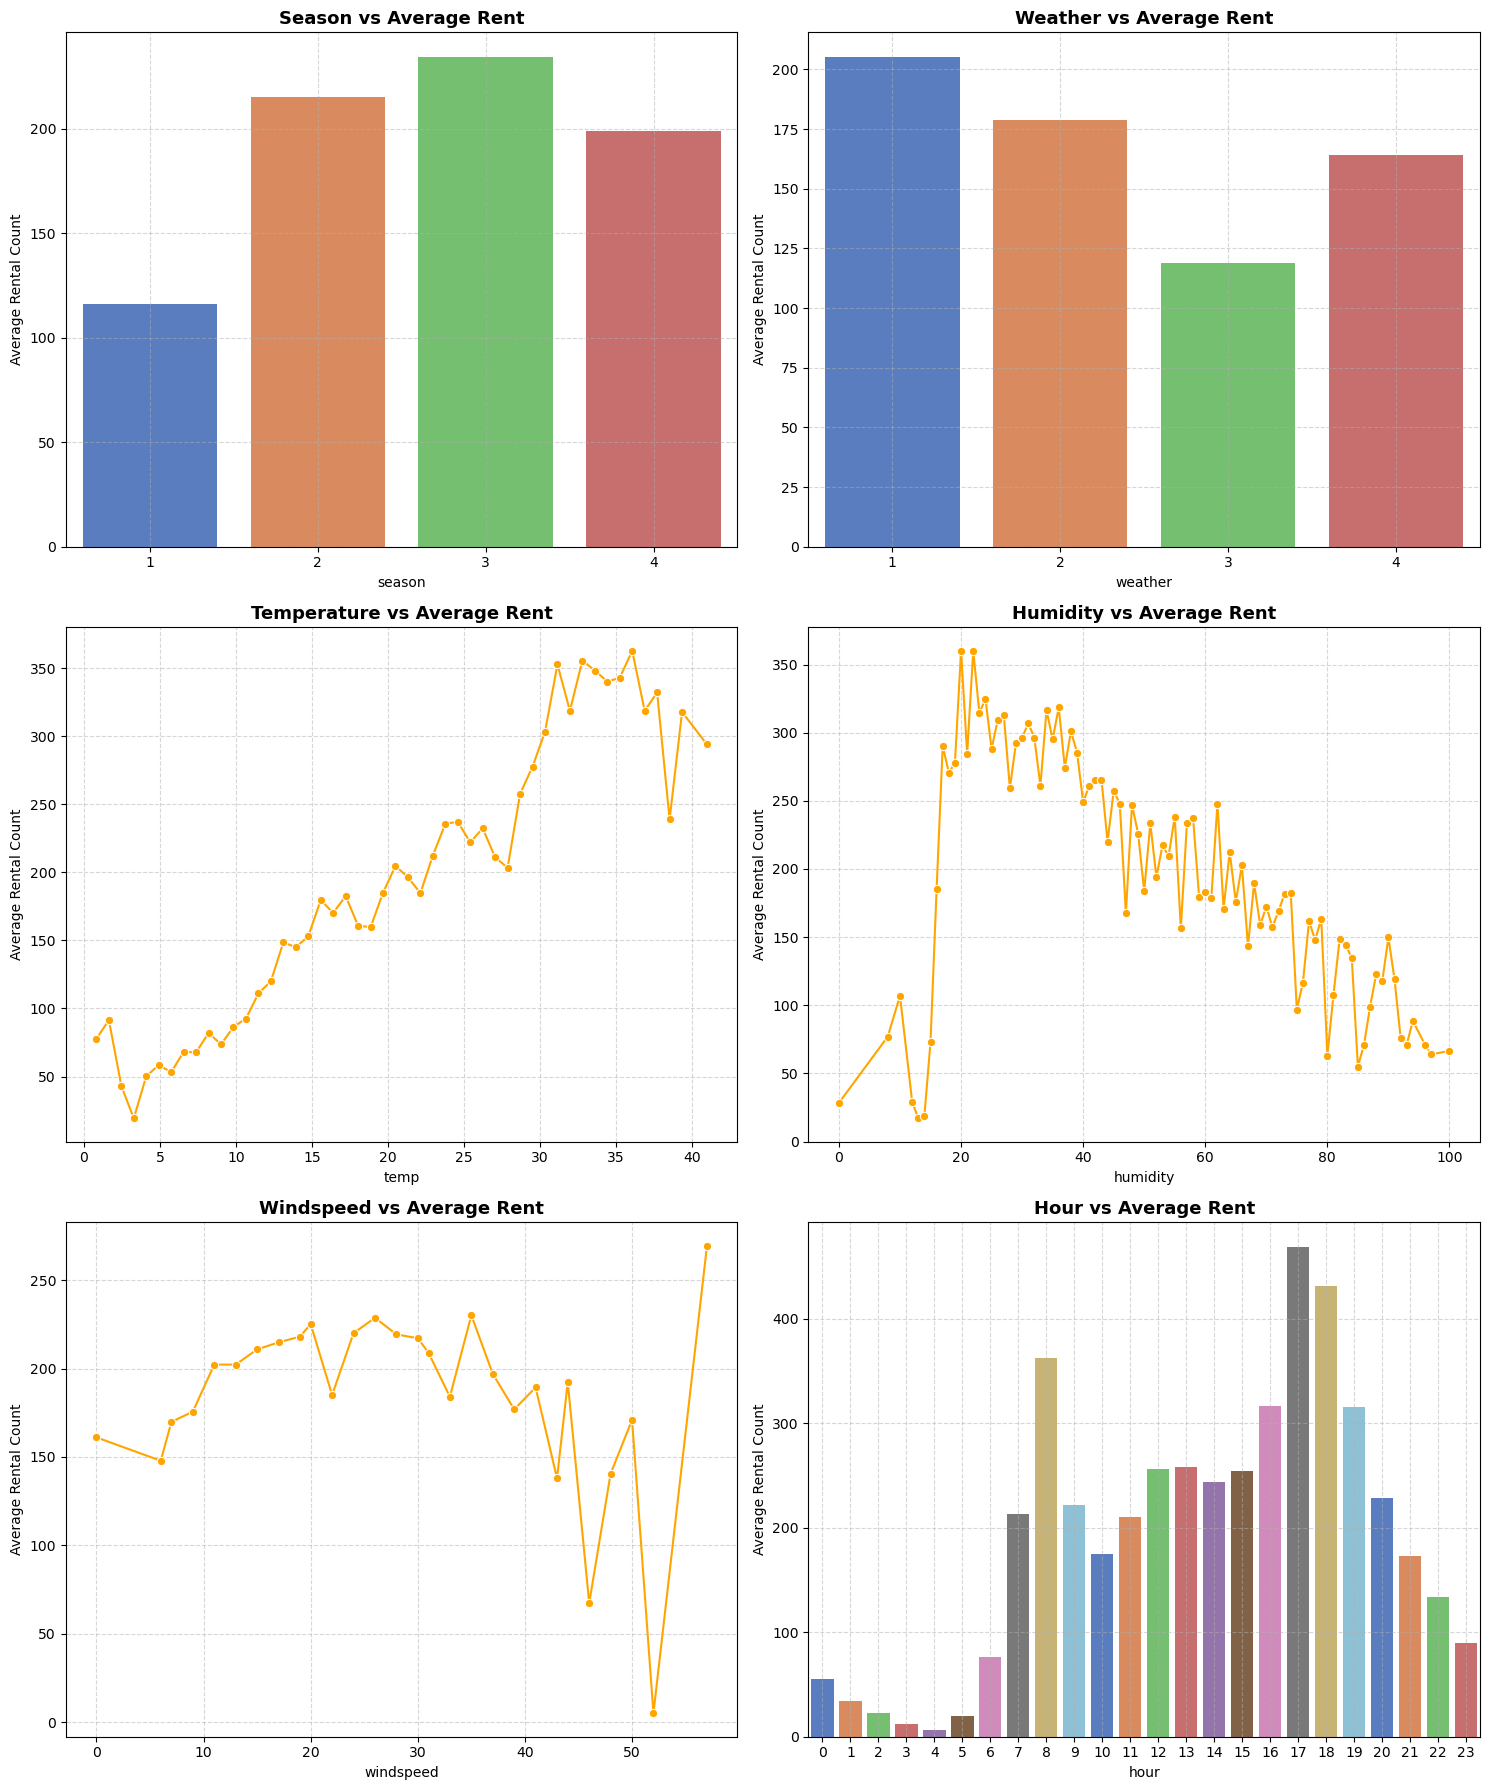

In [18]:
# 어떤 데이터를 feature에 넣을지 확인하기

"""
unique(): "이 안에 무엇 무엇이 들어있나?" (목록 확인용)
value_counts(): "각각 얼마나 많이 들어있나?" (분포 확인용)

###

데이터를 뽑아봤을 때(.unique()등을 이용) 어떤 모습인지가 힌트

연속형 데이터 (숫자가 쭉 이어짐):
예: 기온(temp), 습도(humidity), 풍속(windspeed)
성격: 값이 0.1, 0.2, 0.3 처럼 미세하게 변하거나, 1시, 2시, 3시 처럼 흐름이 있습니다.
선택 그래프: 선 그래프(Line Plot)입니다. "이 숫자가 변할 때 결과가 어떻게 흐르는지"를 봐야 하기 때문입니다.

카테고리형 데이터 (이름표나 구분 값):
예: 날씨(weather), 계절(season), 휴일 여부(holiday)
성격: 1(맑음), 2(흐림), 3(비)처럼 딱딱 끊어집니다. 1과 2 사이의 값은 존재하지 않습니다.
선택 그래프: 막대 그래프(Bar Plot)입니다. "이 그룹(카테고리)별로 높이가 어떻게 차이 나는지"를 비교해야 하기 때문입니다.

* 시간은 "어떻게 바라보느냐(어떤 질문을 던지느냐)"에 따라 연속형일 수도, 카테고리형일 수도
- 연속형(Continuous)으로 볼 때: "흐름"
- 카테고리형(Categorical)으로 볼 때: "특징"
"시간의 흐름에 따른 변화를 관찰하고 싶다" -> 연속형처럼 생각하고 선 그래프로 보세요.
"각 시간대별로 솟아오르는 정답(대여량)의 특징을 모델에게 학습시키고 싶다" -> 카테고리형처럼 생각하고 원-핫 인코딩

###

데이터를 보고 원핫 인코딩을 할지 정하는 순서

1. 데이터가 숫자냐?
아니오(문자): 무조건 인코딩해야 함.
예(숫자): 다음 단계로.

2. 그 숫자가 양을 뜻하느냐?(기온, 풍속 등)
예: 그대로 둔다. (인코딩 X)
아니오: 다음 단계로.

3. 그 숫자가 종류(날씨, 계절)를 뜻하느냐?
예: 원핫 인코딩을 한다.

4. 그 숫자가 등수나 순서(만족도 등)를 뜻하느냐?
예: 라벨 인코딩(또는 그대로 둠)을 한다.

"""

##########

plt.figure(figsize=(7, 5))

# 분석에 사용할 특성들과 정답(count)을 묶어 상관계수 구하기
plot_features = ['count', 'temp', 'atemp', 'season', 'holiday', 'workingday', 'weather', 'humidity', 'windspeed', 'hour', 'month', 'year']
correlation_matrix = train[plot_features].corr()

# 히트맵 그리기 
# annot=True를 넣으면 칸 안에 숫자가 표처럼 박힘
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap', fontweight='bold')
plt.show()
# 0.0대는 너무 낮으니까 제외

##########

# 데이터에 숫자가 어떻게 이루어져 있는지 확인
print(f'season: {train['season'].unique()}')
print(f'weather: {train['weather'].unique()}')
print(f'temp: {train['temp'].unique()}')
print(f'humidity: {train['humidity'].unique()}')
print(f'windspeed: {train['windspeed'].unique()}')

##########


data_list = [
    (train.groupby('season')['count'].mean().reset_index(name='mean_count'), 'Season'),
    (train.groupby('weather')['count'].mean().reset_index(name='mean_count'), 'Weather'),
    (train.groupby('temp')['count'].mean().reset_index(name='mean_count'), 'Temperature'),
    (train.groupby('humidity')['count'].mean().reset_index(name='mean_count'), 'Humidity'),
    (train.groupby('windspeed')['count'].mean().reset_index(name='mean_count'), 'Windspeed'),
    (train.groupby('hour')['count'].mean().reset_index(name='mean_count'), 'Hour')
]

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten() # 2차원 배열을 1차원으로 펼치기

for i, (df, title) in enumerate(data_list):
    ax = axes[i]
    
    # 카테고리형(시즌, 날씨, 시간)은 막대그래프로, 연속형(온도, 습도, 풍속)은 선 그래프로 구분
    if title in ['Season', 'Weather', 'Hour']:
        sns.barplot(data=df, x=df.columns[0], y='mean_count', ax=ax, 
                    hue=df.columns[0], palette='muted', legend=False)
    else:
        sns.lineplot(data=df, x=df.columns[0], y='mean_count', ax=ax, 
                     color='orange', marker='o')
        
    ax.set_title(f'{title} vs Average Rent', fontsize=13, fontweight='bold')
    ax.set_ylabel('Average Rental Count')
    ax.grid(True, linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()


In [19]:
# X, y 컬럼 선택 및 train/test 데이터 분리

features = ['year', 'month', 'hour', 'weather', 'temp', 'humidity']
X = train[features]

# 타깃 설정
y = train['count'] # count 값을 맞추고자 하므로, y 변수에 count 컬럼의 데이터 넣기

# X 데이터 안에서 hour, month, weather만 골라 원핫인코딩으로 쪼개기
X = pd.get_dummies(X, columns=['hour', 'month', 'weather'])

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
# LinearRegression 모델 학습하기
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred = model.predict(X_test) # 학습된 모델에 X_test를 입력해서 예측값 출력하기
mse = mean_squared_error(y_test, y_pred) # 모델이 예측한 값과 정답 target 간의 손실함수 값 계산하기
rmse = np.sqrt(mse) # mse 값과 함께 rmse 값도 계산하기

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 10074.965768483155
RMSE: 100.37412897994759


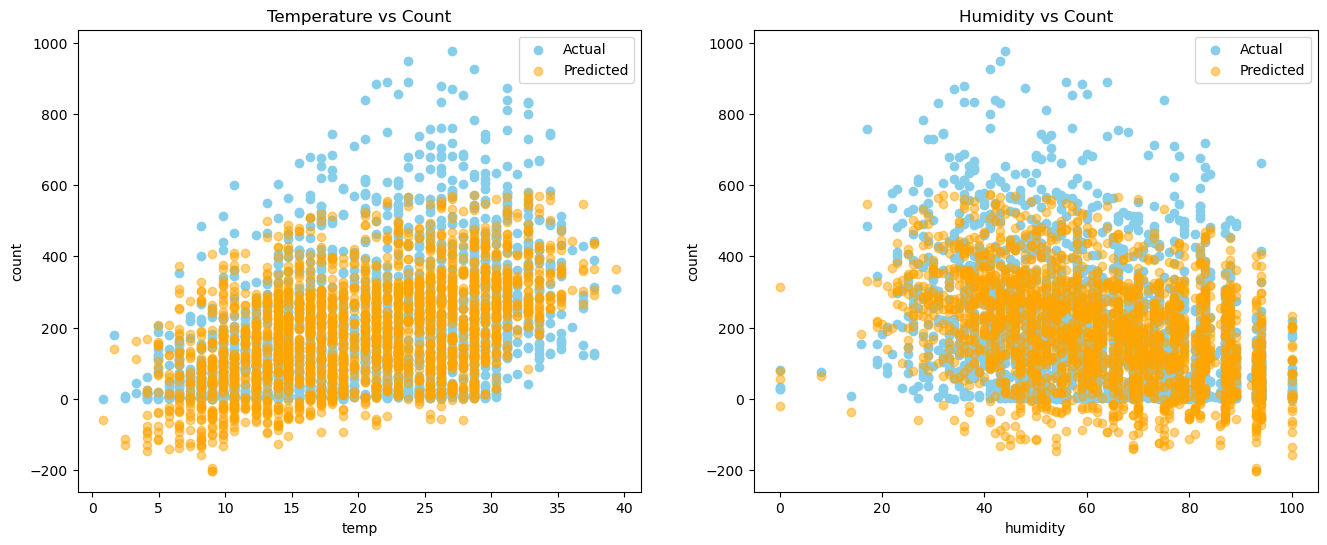

In [22]:
# x축은 temp 또는 humidity로, y축은 count로 예측 결과 시각화하기

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='skyblue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='orange', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()


# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='skyblue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='orange', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()